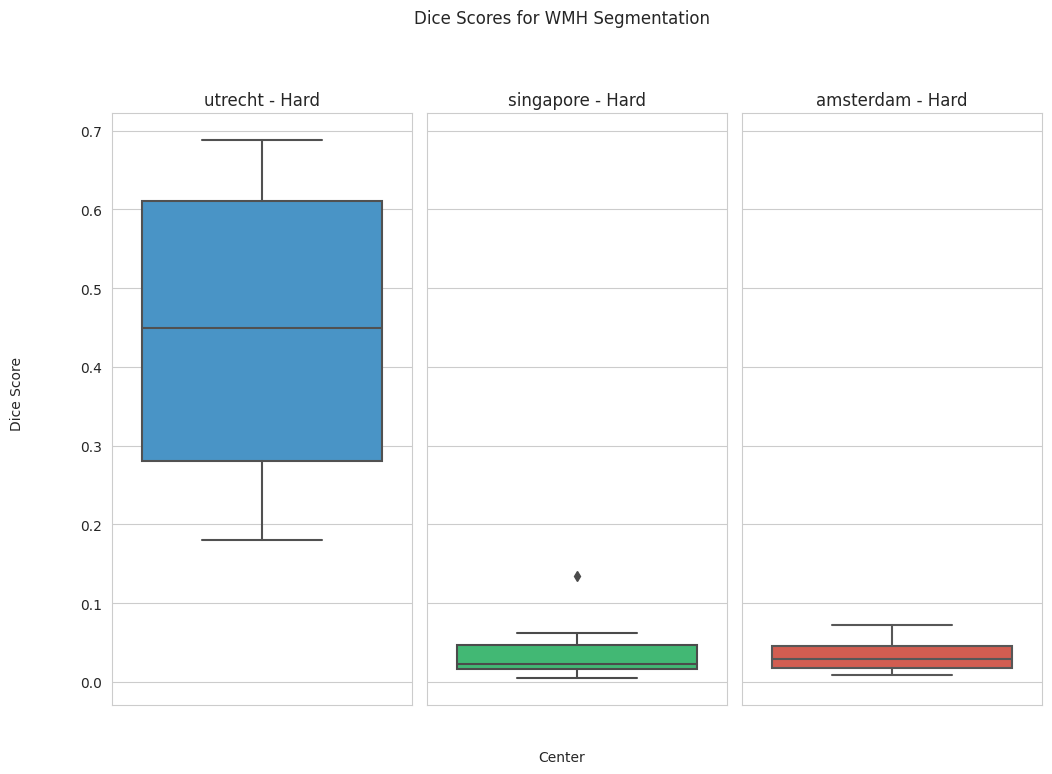

In [16]:
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd

import seaborn as sns

# Set seaborn style
sns.set_style('whitegrid')

# Define colors for each center
colors = ['#3498db', '#2ecc71', '#e74c3c']


def dice_score(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    return 2 * intersection.sum() / (mask1.sum() + mask2.sum())


centers = ['utrecht', 'singapore', 'amsterdam']
results = {}

for center in centers:
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']
    results[center] = {'hard': []}

    for _, row in df.iterrows():
        pred_hard_path, pred_softmax_path, logits_path, gt_path = row

        pred_hard = nib.load(pred_hard_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        # Compute dice scores
        dice_hard = dice_score(pred_hard, gt)

        # Save results in dictionary
        results[center]['hard'].append(dice_hard)

# Create subplots using seaborn's boxplot
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 8), sharey=True)
for i, center in enumerate(centers):
    sns.boxplot(y=results[center]['hard'], color=colors[i], ax=axs[i])
    axs[i].set_title(f"{center} - Hard")

# Set axis labels and title
fig.suptitle('Dice Scores for WMH Segmentation')
fig.text(0.5, 0.04, 'Center', ha='center')
fig.text(0.04, 0.5, 'Dice Score', va='center', rotation='vertical')

# Adjust layout and save plot
fig.subplots_adjust(top=0.85, wspace=0.05)
plt.savefig('dice_scores.png', dpi=300, bbox_inches='tight')



In [12]:
import numpy as np
import pandas as pd
import nibabel as nib
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt


def dice_score(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    return 2 * intersection.sum() / (mask1.sum() + mask2.sum())


def filter_pixels(mask, class_value):
    filtered_mask = np.zeros_like(mask)
    filtered_mask[mask == class_value] = 1
    return filtered_mask


def compute_histogram(predictions, class_value):
    filtered_predictions = filter_pixels(predictions, class_value)
    prob_histogram = np.histogram(filtered_predictions, bins=50, range=(0, 1))[
        0]
    prob_histogram_norm = prob_histogram / prob_histogram.sum()
    return prob_histogram_norm


def reliability_plot(predictions, labels, class_value, ax=None):
    filtered_predictions = filter_pixels(predictions, class_value)
    filtered_labels = filter_pixels(labels, class_value)
    fraction_of_positives, mean_predicted_value = calibration_curve(
        filtered_labels.flatten(), filtered_predictions.flatten(), n_bins=10)

    if not ax:
        fig, ax = plt.subplots()

    ax.plot(mean_predicted_value, fraction_of_positives, "s-",
            label=f"Class {class_value}")
    ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    ax.set_xlabel("Mean predicted value")
    ax.set_ylabel("Fraction of positives")
    ax.legend()
    ax.set_title(f"Reliability Plot - Class {class_value}")


def compute_ece(predictions, labels, n_bins=10):
    confidences = predictions.flatten()
    accuracies = (predictions == labels).flatten().astype(np.float32)

    bin_boundaries = np.histogram_bin_edges(confidences, bins=n_bins)
    bin_confidences = np.zeros(n_bins)
    bin_accuracies = np.zeros(n_bins)

    for i in range(n_bins):
        bin_mask = (confidences >= bin_boundaries[i]) & (
                confidences < bin_boundaries[i + 1])
        bin_confidences[i] = confidences[bin_mask].mean()
        bin_accuracies[i] = accuracies[bin_mask].mean()

    bin_sizes = bin_mask.sum()

    ece = np.abs(bin_accuracies - bin_confidences).mean()

    return ece


centers = ['utrecht', 'singapore', 'amsterdam']
results = {}
for center in centers:
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']
    results[center] = {'hard': [], 'softmax': [], 'logits': []}

    for _, row in df.iterrows():
        pred_hard_path, pred_softmax_path, logits_path, gt_path = row

        # Load predictions and ground truth
        pred_hard = nib.load(pred_hard_path).get_fdata()
        pred_softmax = nib.load(pred_softmax_path).get_fdata()
        pred_logits = nib.load(logits_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        # Compute dice scores
        dice_hard = dice_score(pred_hard, gt)
        dice_softmax = dice_score(np.argmax(pred_softmax, axis=-1), gt)

        # Compute histogram of probabilities
        for class_value in [0, 1, 2]:
            prob_histogram_norm = compute_histogram(
                pred_softmax[..., class_value], class_value)
            results[center]['softmax'].append(
                {'class': class_value, 'histogram': prob_histogram_norm})

        # Compute reliability plots
        for class_value in [0, 1, 2]:
            fig, ax = plt.subplots()
            reliability_plot(pred_softmax[..., class_value], gt, class_value,
                             ax=ax)
            results[center]['softmax'].append(
                {'class': class_value, 'reliability_plot': ax})

        # Compute ECE
        ece_softmax = compute_ece(pred_softmax, gt)

        # Save results in dictionary
        results[center]['hard'].append(dice_hard)
        results[center]['softmax'].append(dice_softmax)
        results[center]['logits'].append({'ece': ece_softmax})
# Plot histograms
for center in centers:
    for class_value in [0, 1, 2]:
        fig, ax = plt.subplots()
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Normalized frequency")
        ax.set_title(
            f"Histogram of predicted probabilities - Class {class_value} ({center})")
        for result in results[center]['softmax']:
            if result['class'] == class_value:
                ax.plot(np.linspace(0, 1, len(result['histogram'])),
                        result['histogram'], label=f"Patient {i}")
        ax.legend()

# Plot reliability plots
for center in centers:
    for class_value in [0, 1, 2]:
        fig, ax = plt.subplots()
        ax.set_xlabel("Mean predicted value")
        ax.set_ylabel("Fraction of positives")
        ax.set_title(f"Reliability plot - Class {class_value} ({center})")
        for result in results[center]['softmax']:
            if result['class'] == class_value:
                ax.plot(result['reliability_plot'].lines[0].get_xdata(),
                        result['reliability_plot'].lines[0].get_ydata(),
                        label=f"Patient {i}")
        ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
        ax.legend()

# Plot ECE
fig, ax = plt.subplots()
ax.set_xlabel("ECE")
ax.set_title("Expected Calibration Error")
for center in centers:
    ax.boxplot(
        [result['logits']['ece'] for result in results[center]['logits']],
        labels=[center], positions=[centers.index(center)])


ValueError: operands could not be broadcast together with shapes (48,240) (48,240,240) 